In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

In [12]:
def load_and_preprocess_data(filepath: str) -> tuple:
    """
    Load housing dataset and perform one-hot encoding.
    Target variable is log-transformed to handle right-skewness.
    """
    df = pd.read_csv(filepath)

    y_log = np.log(df['price'])
    X = df.drop('price', axis=1)

    cat_cols = [
        'mainroad', 'guestroom', 'basement', 'hotwaterheating',
        'airconditioning', 'prefarea', 'furnishingstatus'
    ]

    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

    return X, y_log

X, y_log = load_and_preprocess_data('Housing.csv')

In [13]:
def split_and_scale_data(X: pd.DataFrame, y_log: pd.Series) -> tuple:
    """
    Split data into 80% training and 20% testing sets.
    Apply standard scaling to features.
    """
    X_train, X_test, y_train_log, y_test_log = train_test_split(
        X, y_log, test_size=0.2, random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train_log, y_test_log

X_train_scaled, X_test_scaled, y_train_log, y_test_log = split_and_scale_data(X, y_log)

In [14]:
def evaluate_model(y_true_log: pd.Series, y_pred_log: np.ndarray) -> None:
    """
    Calculate and display RMSE, RRMSE, R-squared, and MAE.
    Values are inverse-transformed (exp) to reflect the original price scale.
    """
    if isinstance(y_true_log, torch.Tensor):
        y_true_log = y_true_log.numpy()

    y_true = np.exp(y_true_log)
    y_pred = np.exp(y_pred_log)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    rrmse = rmse / np.mean(y_true)
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)

    print(f"RMSE: {rmse:,.2f}")
    print(f"RRMSE: {rrmse:.2f}")
    print(f"R^2: {r2:.2f}")
    print(f"MAE: {mae:,.2f}")

def plot_evaluation_metrics(y_true_log: pd.Series, y_pred_log: np.ndarray, title_prefix: str) -> None:
    """
    Generate evaluation plots: Regression, Residuals, and Distribution.
    """
    y_true = np.exp(y_true_log)
    y_pred = np.exp(y_pred_log)
    residuals = y_true - y_pred

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{title_prefix} - Evaluation', fontsize=16)

    axes[0].scatter(y_true, y_pred, alpha=0.5, color='royalblue')
    axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    axes[0].set_xlabel('Actual Values')
    axes[0].set_ylabel('Predicted Values')
    axes[0].set_title('Regression Predictions vs Actual Values')
    axes[0].grid(True, linestyle='--', alpha=0.6)

    axes[1].scatter(y_pred, residuals, alpha=0.5, color='steelblue')
    axes[1].axhline(y=0, color='r', linestyle='--')
    axes[1].set_xlabel('Predicted Values')
    axes[1].set_ylabel('Residuals')
    axes[1].set_title('Residuals vs. Predicted Values')

    sns.histplot(residuals, kde=True, ax=axes[2], color='steelblue', bins=15)
    axes[2].set_xlabel('Residuals')
    axes[2].set_title('Distribution of Residuals')

    plt.tight_layout()
    plt.show()

--- Huấn luyện XGBoost ---
Bộ tham số tốt nhất:
{'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300, 'subsample': 0.6}

RMSE: 1,352,015.72
RRMSE: 0.27
R^2: 0.64
MAE: 976,624.56


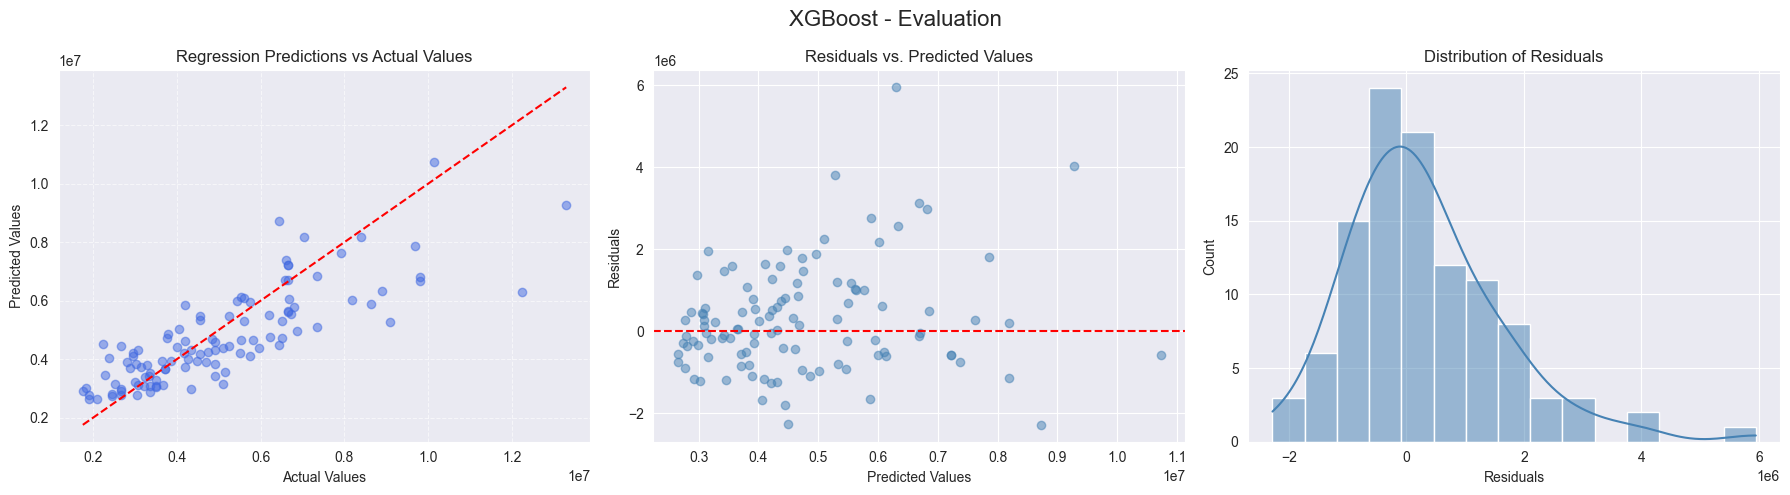

In [21]:
def train_xgboost_model(X_train: np.ndarray, y_train: pd.Series, isBest: bool = True) -> GridSearchCV:
    xgbr = XGBRegressor(random_state=42)

    if not isBest:
        params = {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.01, 0.1],
            'subsample': [0.6, 0.8, 1.0],
            'colsample_bytree': [0.7, 0.8, 1.0],
            'max_depth': [6, 8, 10],
            'gamma': [0.1, 0.3, 0.5],
        }
    else:
        params = {
            'n_estimators': [300],
            'learning_rate': [0.1],
            'subsample': [0.6],
            'colsample_bytree': [0.8],
            'max_depth': [8],
            'gamma': [0.1],
        }

    grid_search = GridSearchCV(
        estimator=xgbr, param_grid=params, cv=5,
        scoring='neg_mean_squared_error', return_train_score=True, n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    return grid_search

print("--- Huấn luyện XGBoost ---")
grid_search_xgb = train_xgboost_model(X_train_scaled, y_train_log, isBest=True)
best_xgb = grid_search_xgb.best_estimator_

print(f"Bộ tham số tốt nhất:\n{grid_search_xgb.best_params_}\n")

y_pred_log_xgb = best_xgb.predict(X_test_scaled)
evaluate_model(y_test_log, y_pred_log_xgb)
plot_evaluation_metrics(y_test_log, y_pred_log_xgb, "XGBoost")

In [16]:
class NeuralNetMLP(nn.Module):
    def __init__(self, in_features=12):
        super(NeuralNetMLP, self).__init__()
        self.layer_1 = nn.Linear(in_features, 64)
        self.act_1 = nn.ReLU()
        self.layer_2 = nn.Linear(64, 128)
        self.act_2 = nn.ReLU()
        self.output_layer = nn.Linear(128, 1)

    def forward(self, input_data):
        out = self.layer_1(input_data)
        out = self.act_1(out)
        out = self.layer_2(out)
        out = self.act_2(out)
        out = self.output_layer(out)
        return out

In [17]:
y_scaler = StandardScaler()

y_train_log_scaled = y_scaler.fit_transform(y_train_log.values.reshape(-1, 1))
y_test_log_scaled = y_scaler.transform(y_test_log.values.reshape(-1, 1))

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_log_scaled, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_log_scaled, dtype=torch.float32)

In [18]:
learning_rate = 0.001
epochs = 35

input_dimension = X_train_scaled.shape[1]

mlp_model = NeuralNetMLP(in_features=input_dimension)

criterion = nn.MSELoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=learning_rate)

train_losses = []
val_losses = []

for epoch in range(epochs):
    mlp_model.train()
    optimizer.zero_grad()

    outputs = mlp_model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    mlp_model.eval()
    with torch.no_grad():
        val_outputs = mlp_model(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor)
        val_losses.append(val_loss.item())

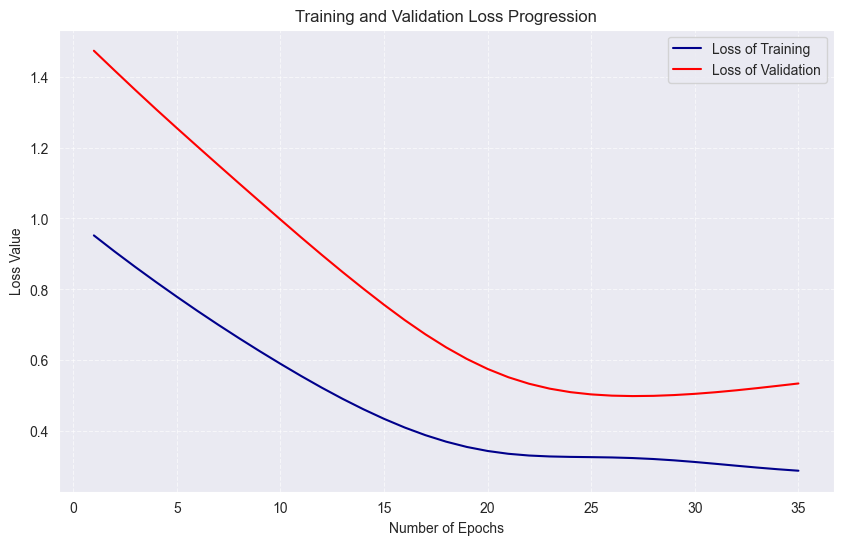

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(range(1, epochs + 1), train_losses, label='Loss of Training', color='darkblue')
plt.plot(range(1, epochs + 1), val_losses, label='Loss of Validation', color='red')

plt.xlabel('Number of Epochs')
plt.ylabel('Loss Value')
plt.title('Training and Validation Loss Progression')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

--- Huấn luyện Mạng Nơ-ron (MLP) ---
RMSE: 1,347,227.33
RRMSE: 0.27
R^2: 0.64
MAE: 956,810.86


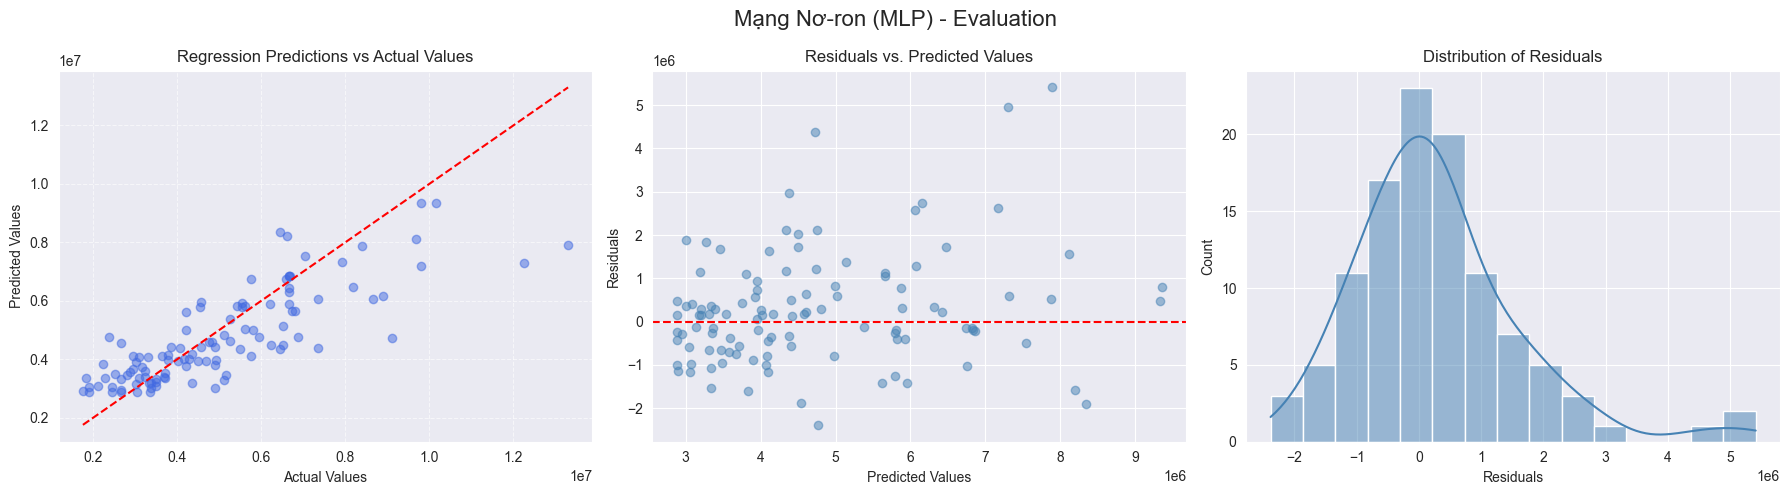

In [20]:
mlp_model.eval()
with torch.no_grad():
    y_pred_scaled_mlp = mlp_model(X_test_tensor).numpy()

    y_pred_log_mlp = y_scaler.inverse_transform(y_pred_scaled_mlp).flatten()

print("--- Huấn luyện Mạng Nơ-ron (MLP) ---")
evaluate_model(y_test_log, y_pred_log_mlp)
plot_evaluation_metrics(y_test_log, y_pred_log_mlp, "Mạng Nơ-ron (MLP)")